In [42]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler , OneHotEncoder
from sklearn.metrics import accuracy_score , precision_score , recall_score ,f1_score , confusion_matrix

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

# Null Values

In [3]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
obj_col=df.select_dtypes(include="object").columns

In [6]:
obj_col

Index(['Month', 'VisitorType'], dtype='object')

In [7]:
num_col=df.select_dtypes(include="number").columns
num_col

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# EDA

Text(0.5, 1.0, 'Revenue Ratio')

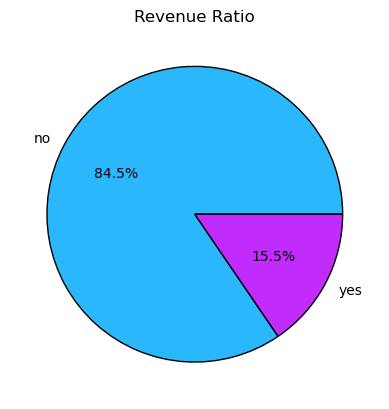

In [9]:
rev_count=df["Revenue"].value_counts()
plt.pie(rev_count,labels=["no","yes"],autopct="%1.1f%%",colors=["#2bb7fb","#c12bfb"],wedgeprops={"edgecolor":"black"})
plt.title("Revenue Ratio")
# very skewed data

In [10]:
df.sample(1)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2609,0,0.0,0,0.0,28,2524.0,0.008929,0.051786,0.0,0.0,May,2,2,1,3,Returning_Visitor,True,False


<Axes: xlabel='Administrative_Duration', ylabel='Count'>

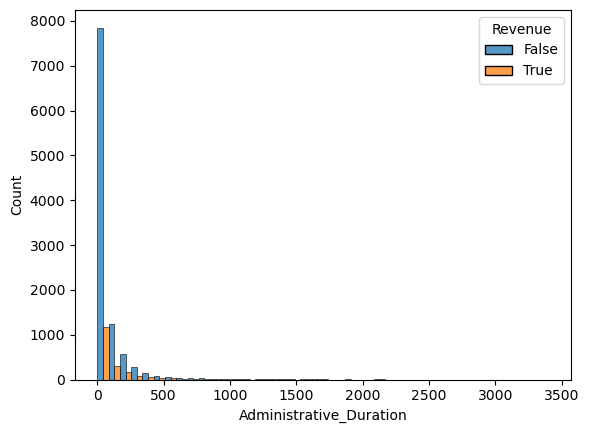

In [11]:
sns.histplot(
    data=df,
    x="Administrative_Duration",
    hue="Revenue",
    bins=40,
    multiple="dodge",
)

In [12]:
num_col

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

Text(0.02, 0.5, 'Feature Count')

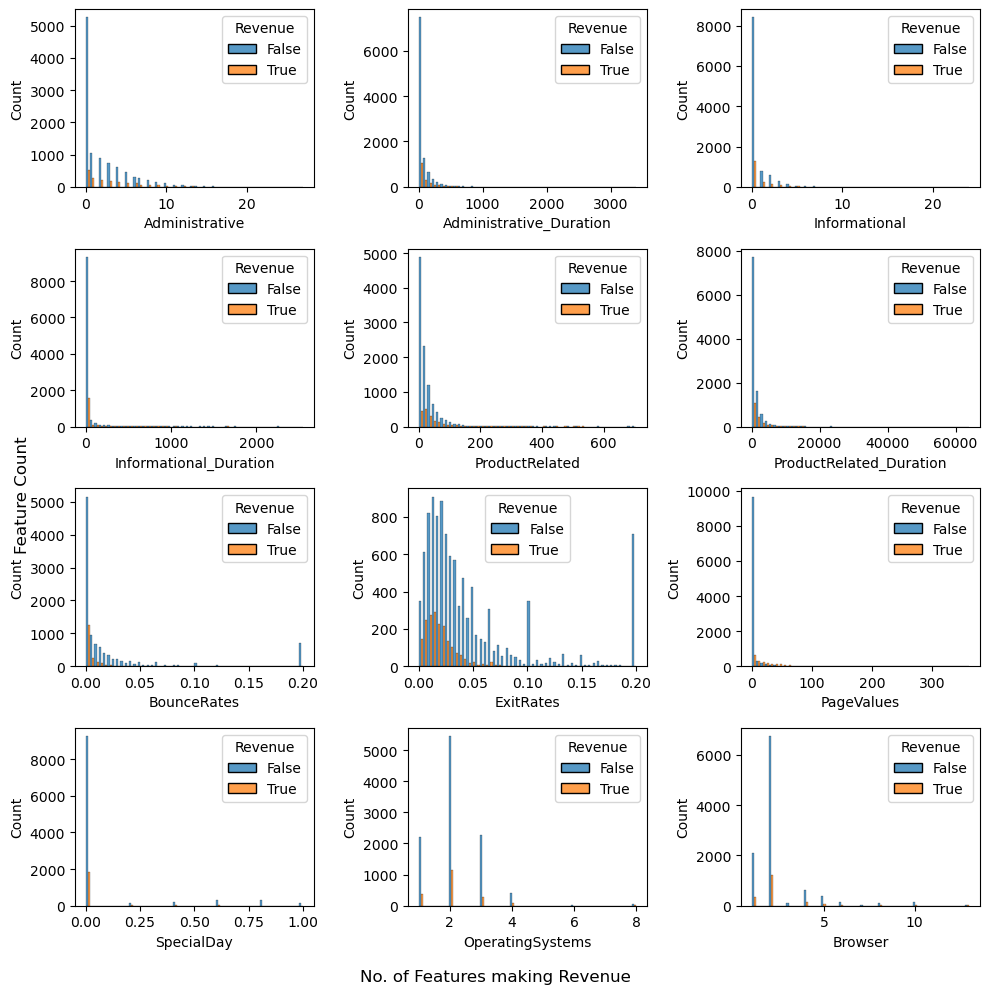

In [13]:
col=0

fig , axes = plt.subplots(4,3, figsize=(10,10))
for i in range(4):
    for j in range(3):
        sns.histplot(
            ax=axes[i,j],
            data=df,
            x=num_col[col],
            hue="Revenue",
            bins=50,
            multiple="dodge",
        )
        col+=1
fig.supxlabel("No. of Features making Revenue")
fig.tight_layout()
fig.supylabel("Feature Count")

In [14]:
obj_col

Index(['Month', 'VisitorType'], dtype='object')

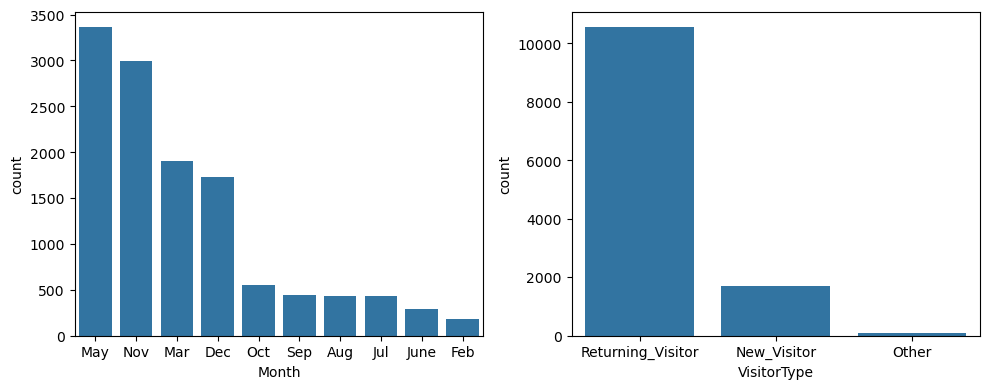

In [15]:
month_count=df["Month"].value_counts()
type_count=df["VisitorType"].value_counts()

fig,axes=plt.subplots(1,2,figsize=(10,4))
sns.barplot(
    ax=axes[0],
    data=month_count
)
sns.barplot(
    ax=axes[1],
    data=type_count
)
fig.tight_layout()

Text(0.5, 1.0, 'Weekend Ratio')

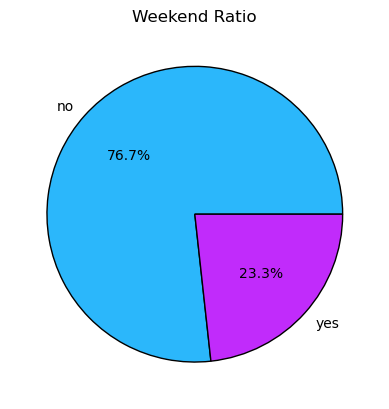

In [35]:
weekend_count=df["Weekend"].value_counts()
plt.pie(weekend_count,labels=["no","yes"],autopct="%1.1f%%",colors=["#2bb7fb","#c12bfb"],wedgeprops={"edgecolor":"black"})
plt.title("Weekend Ratio")

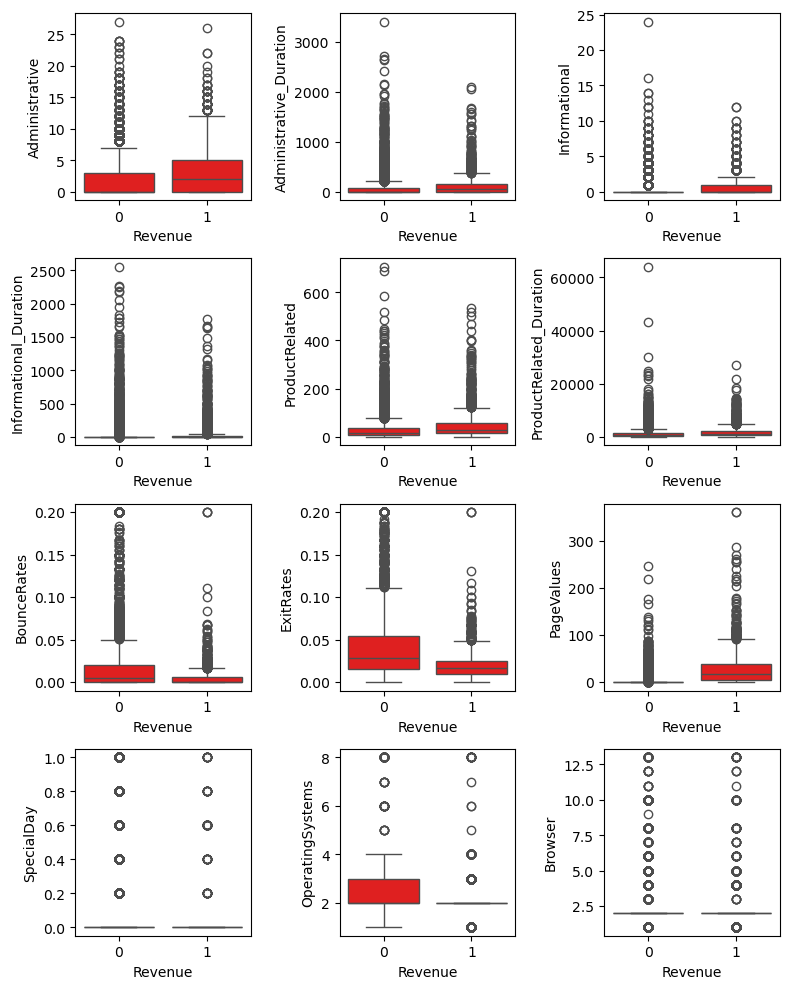

In [85]:
col=0
fig,axes = plt.subplots(4,3,figsize=(8,10))
for i in range(4):
    for j in range(3):
        sns.boxplot(
            ax=axes[i,j],
            data=df,
            x="Revenue",
            y=num_col[col],
            color="red"
        )
        col+=1
fig.tight_layout()

# Encoding 

In [17]:
obj_col

Index(['Month', 'VisitorType'], dtype='object')

In [20]:
ohe=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
values=ohe.fit_transform(df2[obj_col])

In [23]:
df2=pd.DataFrame(values,columns=ohe.get_feature_names_out(obj_col))

In [28]:
df=pd.concat([df.drop(columns=obj_col),df2],axis=1)

In [31]:
le=LabelEncoder()
df["Revenue"]=le.fit_transform(df["Revenue"])
df["Weekend"]=le.fit_transform(df["Weekend"])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

# Feature Selection

In [36]:
X=df.drop(columns=["Revenue"])
y=df["Revenue"]

# Model Selection

In [38]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

# Scaling data

In [41]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression 

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled,Y_train)
Y_pred = model.predict(X_test_scaled)
Y_tpred = model.predict(X_train_scaled)
lr_acc_test = accuracy_score(Y_test,Y_pred)
lr_acc_train = accuracy_score(Y_train,Y_tpred)

lr_prec_test =precision_score(Y_test,Y_pred)
lr_prec_train = precision_score(Y_train,Y_tpred)

lr_recall_test = recall_score(Y_test,Y_pred)
lr_recall_train = recall_score(Y_train,Y_tpred)

lr_f1_test = f1_score(Y_test,Y_pred)
lr_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | { lr_acc_train *100} % \n test | {lr_acc_test *100} % \n')
print(f'precision :\n train | { lr_prec_train *100} % \n test | {lr_prec_test *100} %\n')
print(f'recall :\n train | { lr_recall_train *100} % \n test | {lr_recall_test *100} %\n')
print(f'f1 :\n train | { lr_f1_train *100} % \n test | {lr_f1_test *100} %')
print(f'\nconfusion metrics : \n{confusion_matrix(Y_test,Y_pred)}')


accuracy :
 train | 88.56447688564477 % 
 test | 88.32116788321169 % 

precision :
 train | 75.29239766081871 % 
 test | 76.57992565055763 %

recall :
 train | 38.63465866466617 % 
 test | 35.82608695652174 %

f1 :
 train | 51.0659395141299 % 
 test | 48.81516587677725 %

confusion metrics : 
[[3061   63]
 [ 369  206]]


# DecisionTree 

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("dt",DecisionTreeClassifier())
])
param={
    "dt__max_depth":[3,4,5,6,7],
    "dt__min_samples_split":[2,3,4],
    "dt__min_samples_leaf":[2,3,4]
}
model=GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring="f1"
)

model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

dt_acc_test = accuracy_score(Y_test,Y_pred)
dt_acc_train = accuracy_score(Y_train,Y_tpred)

dt_prec_test =precision_score(Y_test,Y_pred)
dt_prec_train = precision_score(Y_train,Y_tpred)

dt_recall_test = recall_score(Y_test,Y_pred)
dt_recall_train = recall_score(Y_train,Y_tpred)

dt_f1_test = f1_score(Y_test,Y_pred)
dt_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | {dt_acc_train *100} % \n test | {dt_acc_test *100} % \n')
print(f'precision :\n train | { dt_prec_train *100} % \n test | {dt_prec_test *100} %\n')
print(f'recall :\n train | { dt_recall_train *100} % \n test | {dt_recall_test *100} %\n')
print(f'f1 :\n train | { dt_f1_train *100} % \n test | {dt_f1_test *100} %\n')

print(model.best_params_)
print(f'\nconfusion metrics : \n{confusion_matrix(Y_test,Y_pred)}')

accuracy :
 train | 90.18653690186537 % 
 test | 89.213300892133 % 

precision :
 train | 70.62818336162988 % 
 test | 67.60000000000001 %

recall :
 train | 62.41560390097525 % 
 test | 58.78260869565217 %

f1 :
 train | 66.268418956591 % 
 test | 62.883720930232556 %

{'dt__max_depth': 3, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 2}

confusion metrics : 
[[2962  162]
 [ 237  338]]


# RandomForest

In [68]:
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("rf",RandomForestClassifier(max_depth=7,min_samples_split=2,min_samples_leaf=4))
])
param={
    "rf__n_estimators":[100,300]
}
model=GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring="f1"
)

model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

rf_acc_test = accuracy_score(Y_test,Y_pred)
rf_acc_train = accuracy_score(Y_train,Y_tpred)

rf_prec_test =precision_score(Y_test,Y_pred)
rf_prec_train = precision_score(Y_train,Y_tpred)

rf_recall_test = recall_score(Y_test,Y_pred)
rf_recall_train = recall_score(Y_train,Y_tpred)

rf_f1_test = f1_score(Y_test,Y_pred)
rf_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | { rf_acc_train *100} % \n test | {rf_acc_test *100} % \n')
print(f'precision :\n train | { rf_prec_train *100} % \n test | {rf_prec_test *100} %\n')
print(f'recall :\n train | { rf_recall_train *100} % \n test | {rf_recall_test *100} %\n')
print(f'f1 :\n train | { rf_f1_train *100} % \n test | {rf_f1_test *100} %\n')

print(model.best_params_)
print(f'\nconfusion metrics : \n{confusion_matrix(Y_test,Y_pred)}')

accuracy :
 train | 91.97080291970804 % 
 test | 90.18653690186537 % 

precision :
 train | 85.39823008849558 % 
 test | 78.34224598930481 %

recall :
 train | 57.91447861965492 % 
 test | 50.95652173913044 %

f1 :
 train | 69.02101028162718 % 
 test | 61.74920969441517 %

{'rf__n_estimators': 300}

confusion metrics : 
[[3043   81]
 [ 282  293]]


# Gaussian Naive Bayes

In [61]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train_scaled,Y_train)
Y_pred = model.predict(X_test_scaled)
Y_tpred = model.predict(X_train_scaled)
gb_acc_test = accuracy_score(Y_test,Y_pred)
gb_acc_train = accuracy_score(Y_train,Y_tpred)

gb_prec_test =precision_score(Y_test,Y_pred)
gb_prec_train = precision_score(Y_train,Y_tpred)

gb_recall_test = recall_score(Y_test,Y_pred)
gb_recall_train = recall_score(Y_train,Y_tpred)

gb_f1_test = f1_score(Y_test,Y_pred)
gb_f1_train = f1_score(Y_train,Y_tpred)

print(f'accuracy :\n train | { gb_acc_train *100} % \n test | {gb_acc_test *100} % \n')
print(f'precision :\n train | { gb_prec_train *100} % \n test | {gb_prec_test *100} %\n')
print(f'recall :\n train | { gb_recall_train *100} % \n test | {gb_recall_test *100} %\n')
print(f'f1 :\n train | { gb_f1_train *100} % \n test | {gb_f1_test *100} %')

accuracy :
 train | 67.38500753099294 % 
 test | 67.53176534198431 % 

precision :
 train | 30.048465266558967 % 
 test | 30.139593908629443 %

recall :
 train | 83.72093023255815 % 
 test | 82.6086956521739 %

f1 :
 train | 44.224291658410934 % 
 test | 44.16550441655044 %


In [70]:
train_f1 =[lr_f1_train, gb_f1_train, rf_f1_train, dt_f1_train]
test_f1 =[lr_f1_test , gb_f1_test, rf_f1_test, dt_f1_test]

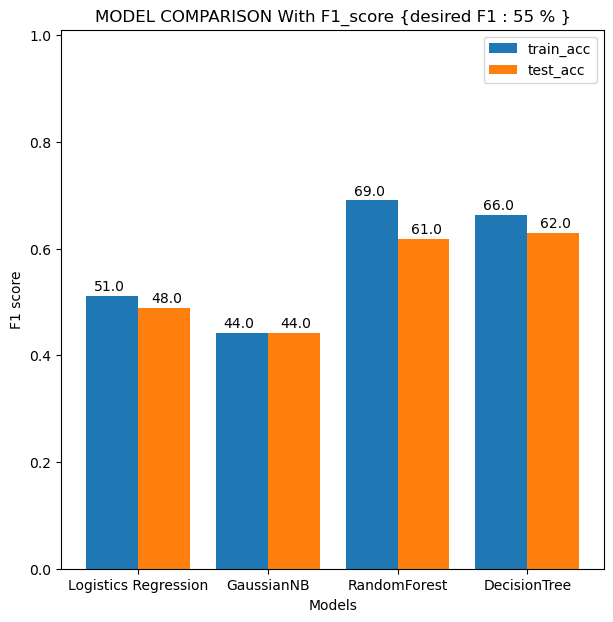

In [75]:
X=np.array([1,2,3,4])
name=["Logistics Regression","GaussianNB","RandomForest","DecisionTree"]
train_f1 =[lr_f1_train, gb_f1_train, rf_f1_train, dt_f1_train]
test_f1 =[lr_f1_test , gb_f1_test, rf_f1_test, dt_f1_test]
width=0.40
plt.figure(figsize=(7,7))
plt.bar( X- width/2, train_f1,width,label="train_acc")
plt.bar( X+ width/2, test_f1,width,label="test_acc")
plt.title("MODEL COMPARISON With F1_score {desired F1 : 55 % }")
plt.xlabel("Models")
plt.ylabel("F1 score")
plt.ylim(0,1+0.01)
plt.xticks(X,name)
plt.legend()

for i in range(len(name)):
    plt.text(X[i]-0.1,train_f1[i]+0.01,str(train_f1[i]*100//1), ha="right")
    plt.text(X[i]+0.1,test_f1[i]+0.01,str(test_f1[i]*100//1), ha="left")

plt.savefig("Model_f1_score.png")